# Laboratorio 6: AutoML + Taller Bono
## MINE 4206 - Analisis con Machine Learning - 2026-10

---

**Contexto del problema:** Predecir los valores de medición de polución en el aire a partir de información de temperatura, humedad y 5 sensores específicos de medición. Se cuenta con tres variables objetivo: `target_carbon_monoxide`, `target_benzene` y `target_nitrogen_oxides`. Los datos provienen de la competencia [Tabular Playground Series - Jul 2021](https://www.kaggle.com/competitions/tabular-playground-series-jul-2021/data) de Kaggle.

**Objetivo:**

1. **Parte A (lab base):** reproducir el ejercicio del laboratorio: preparación de datos, feature engineering temporal, escalado logarítmico de targets, exploración y entrenamiento de un modelo AutoML con FLAML por cada target.

2. **Parte B (taller bono):** desarrollar los tres puntos del bono:
    - **Punto 1.** Realizar transformaciones adicionales (escalado de features, variables cíclicas, interacciones entre sensores, lags temporales) y reentrenar AutoML. Cuadro comparativo entre modelo base y modelo mejorado.
    - **Punto 2.** Justificar por qué los modelos seleccionados por FLAML para cada target son los más adecuados, basándose en teoría del algoritmo y contexto del problema.
    - **Punto 3.** Entrenamiento encadenado: usar las predicciones de `target_carbon_monoxide` y `target_benzene` como variables adicionales para predecir `target_nitrogen_oxides`. Comparar contra el modelo base. Implementar ambas variantes (predicciones in-sample y out-of-fold) para discutir el riesgo de data leakage.

## 0. Importación de Librerías

In [3]:
# Instalación de librerías (usar sys.executable garantiza que se instalen
# en el mismo intérprete de Python que está ejecutando este notebook).
import sys
!{sys.executable} -m pip install "flaml[automl]" seaborn scikit-learn kneed


In [4]:
# Librerías básicas
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado con AutoML
from flaml import AutoML

# Preprocesamiento y validación
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

# Semilla global para reproducibilidad
SEED = 42
np.random.seed(SEED)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
# **Parte A: Laboratorio Base**

Reproducción del laboratorio guiado por el tutor (Nicolás Tibatá). Esta parte sienta la línea base con la que se compararán las mejoras del bono.

## 1. Carga y exploración de los datos

### 1.1 Carga del dataset

In [5]:
# Ruta a los datos
RUTA_DATOS = './Datos'

# Carga
train_data = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
test_data = pd.read_csv(os.path.join(RUTA_DATOS, 'test.csv'))
targets = ['target_carbon_monoxide', 'target_benzene', 'target_nitrogen_oxides']

print(f"Dimensiones train: {train_data.shape[0]} filas × {train_data.shape[1]} columnas")
print(f"Dimensiones test:  {test_data.shape[0]} filas × {test_data.shape[1]} columnas")
print(f"\nColumnas en train:")
for i, col in enumerate(train_data.columns, 1):
    print(f"  {i}. {col}")

Dimensiones train: 7111 filas × 12 columnas
Dimensiones test:  2247 filas × 9 columnas

Columnas en train:
  1. date_time
  2. deg_C
  3. relative_humidity
  4. absolute_humidity
  5. sensor_1
  6. sensor_2
  7. sensor_3
  8. sensor_4
  9. sensor_5
  10. target_carbon_monoxide
  11. target_benzene
  12. target_nitrogen_oxides


In [6]:
# Vista de las primeras filas
train_data.head(10)

,date_time,deg_C,relative_humidity,absolute_humidity,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,target_carbon_monoxide,target_benzene,target_nitrogen_oxides
0,2010-03-10 18:00:00,13.1,46.0,0.7578,1387.2,1087.8,1056.0,1742.8,1293.4,2.5,12.0,167.7
1,2010-03-10 19:00:00,13.2,45.3,0.7255,1279.1,888.2,1197.5,1449.9,1010.9,2.1,9.9,98.9
2,2010-03-10 20:00:00,12.6,56.2,0.7502,1331.9,929.6,1060.2,1586.1,1117.0,2.2,9.2,127.1
3,2010-03-10 21:00:00,11.0,62.4,0.7867,1321.0,929.0,1102.9,1536.5,1263.2,2.2,9.7,177.2
4,2010-03-10 22:00:00,11.9,59.0,0.7888,1272.0,852.7,1180.9,1415.5,1132.2,1.5,6.4,121.8
5,2010-03-10 23:00:00,11.2,56.8,0.7848,1220.9,697.5,1417.2,1462.6,949.0,1.2,4.4,88.1
6,2010-03-11 00:00:00,10.7,55.7,0.7603,1244.2,669.3,1491.2,1413.0,769.6,1.2,3.7,59.5
7,2010-03-11 01:00:00,10.3,57.0,0.7702,1181.4,631.7,1511.1,1359.7,715.4,1.0,3.4,63.9
8,2010-03-11 02:00:00,10.1,62.7,0.7648,1159.6,602.9,1610.6,1212.2,657.2,0.9,2.2,46.4
9,2010-03-11 03:00:00,10.5,59.6,0.7517,1030.2,521.7,1790.2,1148.6,491.0,0.6,1.6,43.0


### 1.2 Información estructural

In [7]:
# Información de tipos y valores no nulos
print("=== Información del Dataset ===")
train_data.info()

=== Información del Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7111 entries, 0 to 7110
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date_time               7111 non-null   object 
 1   deg_C                   7111 non-null   float64
 2   relative_humidity       7111 non-null   float64
 3   absolute_humidity       7111 non-null   float64
 4   sensor_1                7111 non-null   float64
 5   sensor_2                7111 non-null   float64
 6   sensor_3                7111 non-null   float64
 7   sensor_4                7111 non-null   float64
 8   sensor_5                7111 non-null   float64
 9   target_carbon_monoxide  7111 non-null   float64
 10  target_benzene          7111 non-null   float64
 11  target_nitrogen_oxides  7111 non-null   float64
dtypes: float64(11), object(1)
memory usage: 666.8+ KB


In [8]:
# Verificación de nulos y rango temporal
print("=== Análisis de Valores Faltantes ===")
nulos = train_data.isnull().sum()
if nulos.sum() == 0:
    print("✓ No hay valores nulos en el dataset.\n")
else:
    print(nulos[nulos > 0])

print("=== Rango temporal ===")
print(f"Train: {train_data['date_time'].min()} → {train_data['date_time'].max()}")
print(f"Test:  {test_data['date_time'].min()} → {test_data['date_time'].max()}")

# Verificar si la frecuencia es horaria
fechas_train = pd.to_datetime(train_data['date_time'])
diffs = fechas_train.diff().dropna()
print(f"\nFrecuencia temporal (moda de diferencias): {diffs.mode().iloc[0]}")

=== Análisis de Valores Faltantes ===
✓ No hay valores nulos en el dataset.

=== Rango temporal ===
Train: 2010-03-10 18:00:00 → 2011-01-01 00:00:00
Test:  2011-01-01 00:00:00 → 2011-04-04 14:00:00

Frecuencia temporal (moda de diferencias): 0 days 01:00:00


### 1.3 Estadísticos descriptivos de las variables objetivo

In [9]:
# Resumen estadístico de los targets
print("=== Estadísticos descriptivos de los targets ===\n")
print(train_data[targets].describe().round(2))

=== Estadísticos descriptivos de los targets ===

       target_carbon_monoxide  target_benzene  target_nitrogen_oxides
count                 7111.00         7111.00                 7111.00
mean                     2.09           10.24                  204.07
std                      1.45            7.69                  193.93
min                      0.10            0.10                    1.90
25%                      1.00            4.50                   76.45
50%                      1.70            8.50                  141.00
75%                      2.80           14.20                  260.00
max                     12.50           63.70                 1472.30


## 2. Preparación y Feature Engineering (base)

Se replica el feature engineering del laboratorio guiado: extracción de variables de fecha y log-scaling de los targets.

### 2.1 Variables temporales a partir de `date_time`

In [10]:
# Feature engineering temporal (igual al laboratorio guiado)
def date_features(df):
    """
    Extrae variables temporales desde la columna date_time:
    year, month, day, time (días transcurridos), hour, day_of_week.
    Aplica one-hot encoding sobre day_of_week.
    """
    df_t = df.copy()
    df_t['date_time'] = pd.to_datetime(df_t['date_time'])
    df_t['year']  = df_t['date_time'].dt.year
    df_t['month'] = df_t['date_time'].dt.month
    df_t['day']   = df_t['date_time'].dt.day
    df_t['time']  = df_t['date_time'].dt.date - df_t['date_time'].dt.date.min()
    df_t['time']  = df_t['time'].apply(lambda x: x.days)
    df_t['hour']  = df_t['date_time'].dt.hour
    df_t['day_of_week'] = df_t['date_time'].dt.dayofweek.astype('object')
    df_t = pd.get_dummies(df_t, dtype=int)
    df_t.drop(columns='date_time', inplace=True)
    return df_t


train_data_featured = date_features(train_data)
test_data_featured  = date_features(test_data)

print(f"train con features: {train_data_featured.shape}")
print(f"test  con features: {test_data_featured.shape}")
print(f"\nColumnas tras feature engineering:")
print(list(train_data_featured.columns))

train con features: (7111, 23)
test  con features: (2247, 20)

Columnas tras feature engineering:
['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'target_carbon_monoxide', 'target_benzene', 'target_nitrogen_oxides', 'year', 'month', 'day', 'time', 'hour', 'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'day_of_week_6']


### 2.2 Distribución de los targets antes del escalado

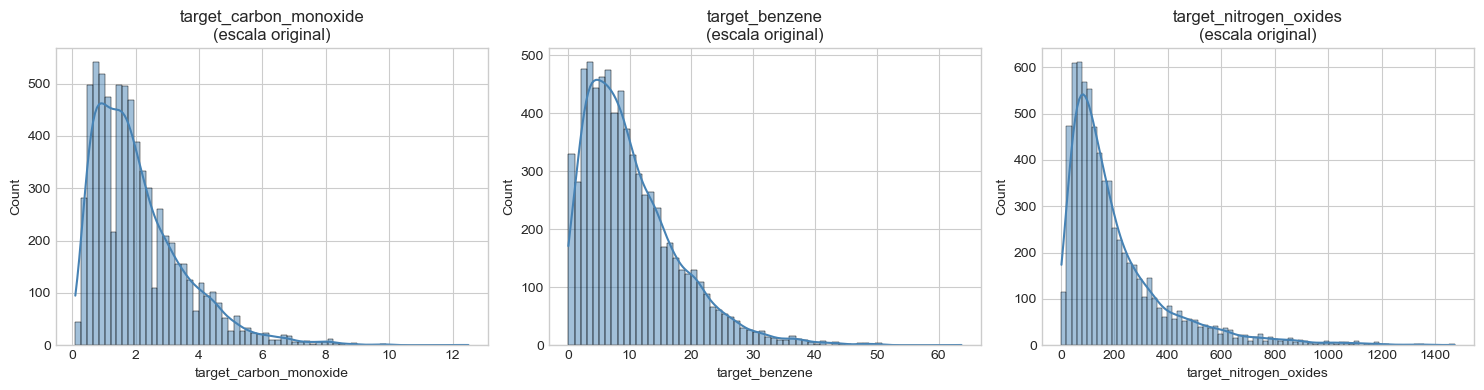

In [11]:
# Histogramas de los targets en escala original
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, target in zip(axs, targets):
    sns.histplot(train_data[target], ax=ax, kde=True, color='steelblue')
    ax.set_title(f"{target}\n(escala original)")
    ax.set_xlabel(target)
plt.tight_layout()
plt.show()

**Observación:** Los tres targets presentan **sesgo positivo** (cola larga a la derecha). Esto se confirma con los estadísticos descriptivos: el valor máximo es mucho mayor que la mediana y la media supera a la mediana. Para modelos de regresión es deseable que la variable objetivo tenga una distribución cercana a la normal, por lo que se aplicará una transformación logarítmica (`log1p`).

### 2.3 Escalado logarítmico de los targets

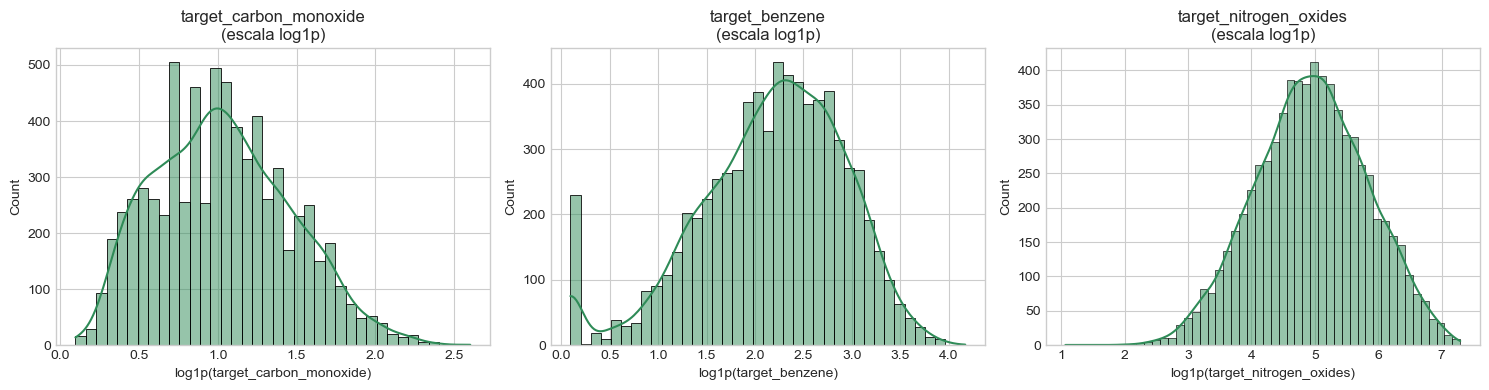

In [12]:
# Aplicación de log1p a los targets en el conjunto de entrenamiento
def scaler(col):
    return np.log1p(col)

for target in targets:
    train_data_featured[target] = scaler(train_data_featured[target])

# Visualización tras el escalado
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, target in zip(axs, targets):
    sns.histplot(train_data_featured[target], ax=ax, kde=True, color='seagreen')
    ax.set_title(f"{target}\n(escala log1p)")
    ax.set_xlabel(f"log1p({target})")
plt.tight_layout()
plt.show()

**Reflexión del lab:** *"Podemos aplicarle ahora un standard o min-max scaler para que mantenga una escala compartida?"*

En el modelo base **no se aplica un escalado adicional sobre los targets** porque los modelos basados en árboles (LightGBM, XGBoost, Random Forest), que son los que típicamente domina FLAML en problemas tabulares, son **invariantes a transformaciones monótonas** de los predictores y a la escala absoluta del target (lo que importa es la estructura relativa, no las magnitudes). Para modelos lineales sí valdría la pena, pero como FLAML evalúa muchas familias y suele quedarse con árboles, es preferible mantener la interpretabilidad del target en escala log y revertir la transformación al final si fuera necesario.

En la Parte B del bono sí se explorará escalado sobre las **features**, donde tiene mayor sentido para acelerar la convergencia de modelos lineales y SGD que también prueba FLAML.

### 2.4 Análisis de correlaciones

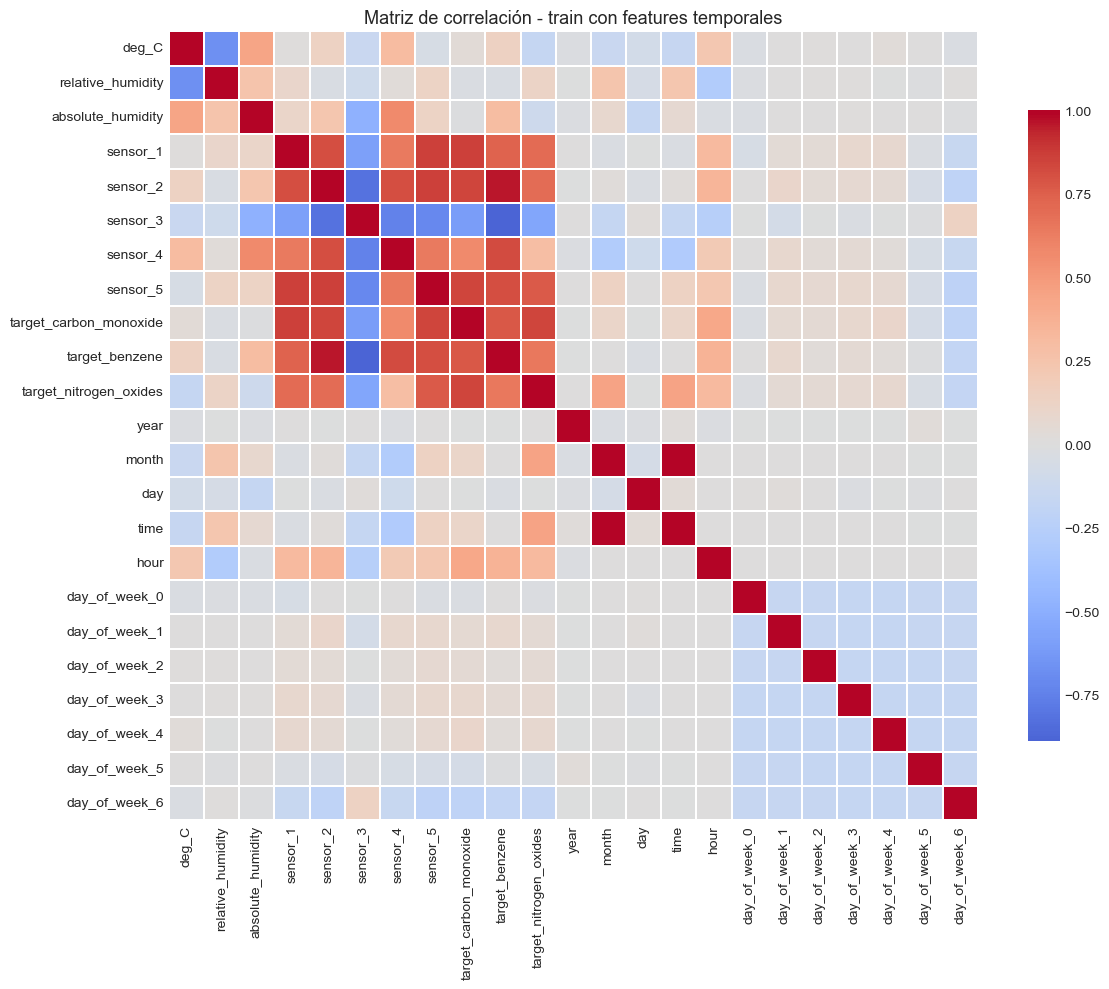

In [13]:
# Matriz de correlación entre todas las variables del dataset featured
plt.figure(figsize=(12, 10))
corr_matrix = train_data_featured.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación - train con features temporales', fontsize=13)
plt.tight_layout()
plt.show()

**Observación del lab:** *"El sensor 3 se comporta de manera distinta a los demás. Esto es algo importante para el modelado?"*

Sí, es relevante. Los sensores 1, 2, 4 y 5 muestran correlaciones positivas fuertes entre sí y con los targets, lo cual sugiere que están capturando una señal común relacionada con los niveles de contaminantes. **El sensor 3, en cambio, presenta correlación negativa o muy baja** con los otros sensores y los targets — probablemente mide una propiedad ortogonal o complementaria (por ejemplo, podría estar inversamente relacionado con la concentración del gas que mide, o ser un sensor de referencia). Esto es información valiosa para el modelo:

- **No se debe eliminar** aunque tenga baja correlación lineal: los modelos no lineales (árboles) pueden aprovechar interacciones que la correlación lineal no captura.
- **Es candidato natural para interacciones**: en la Parte B exploramos productos `sensor_3 × sensor_otros` como features adicionales.

### 2.5 Patrones temporales en los targets

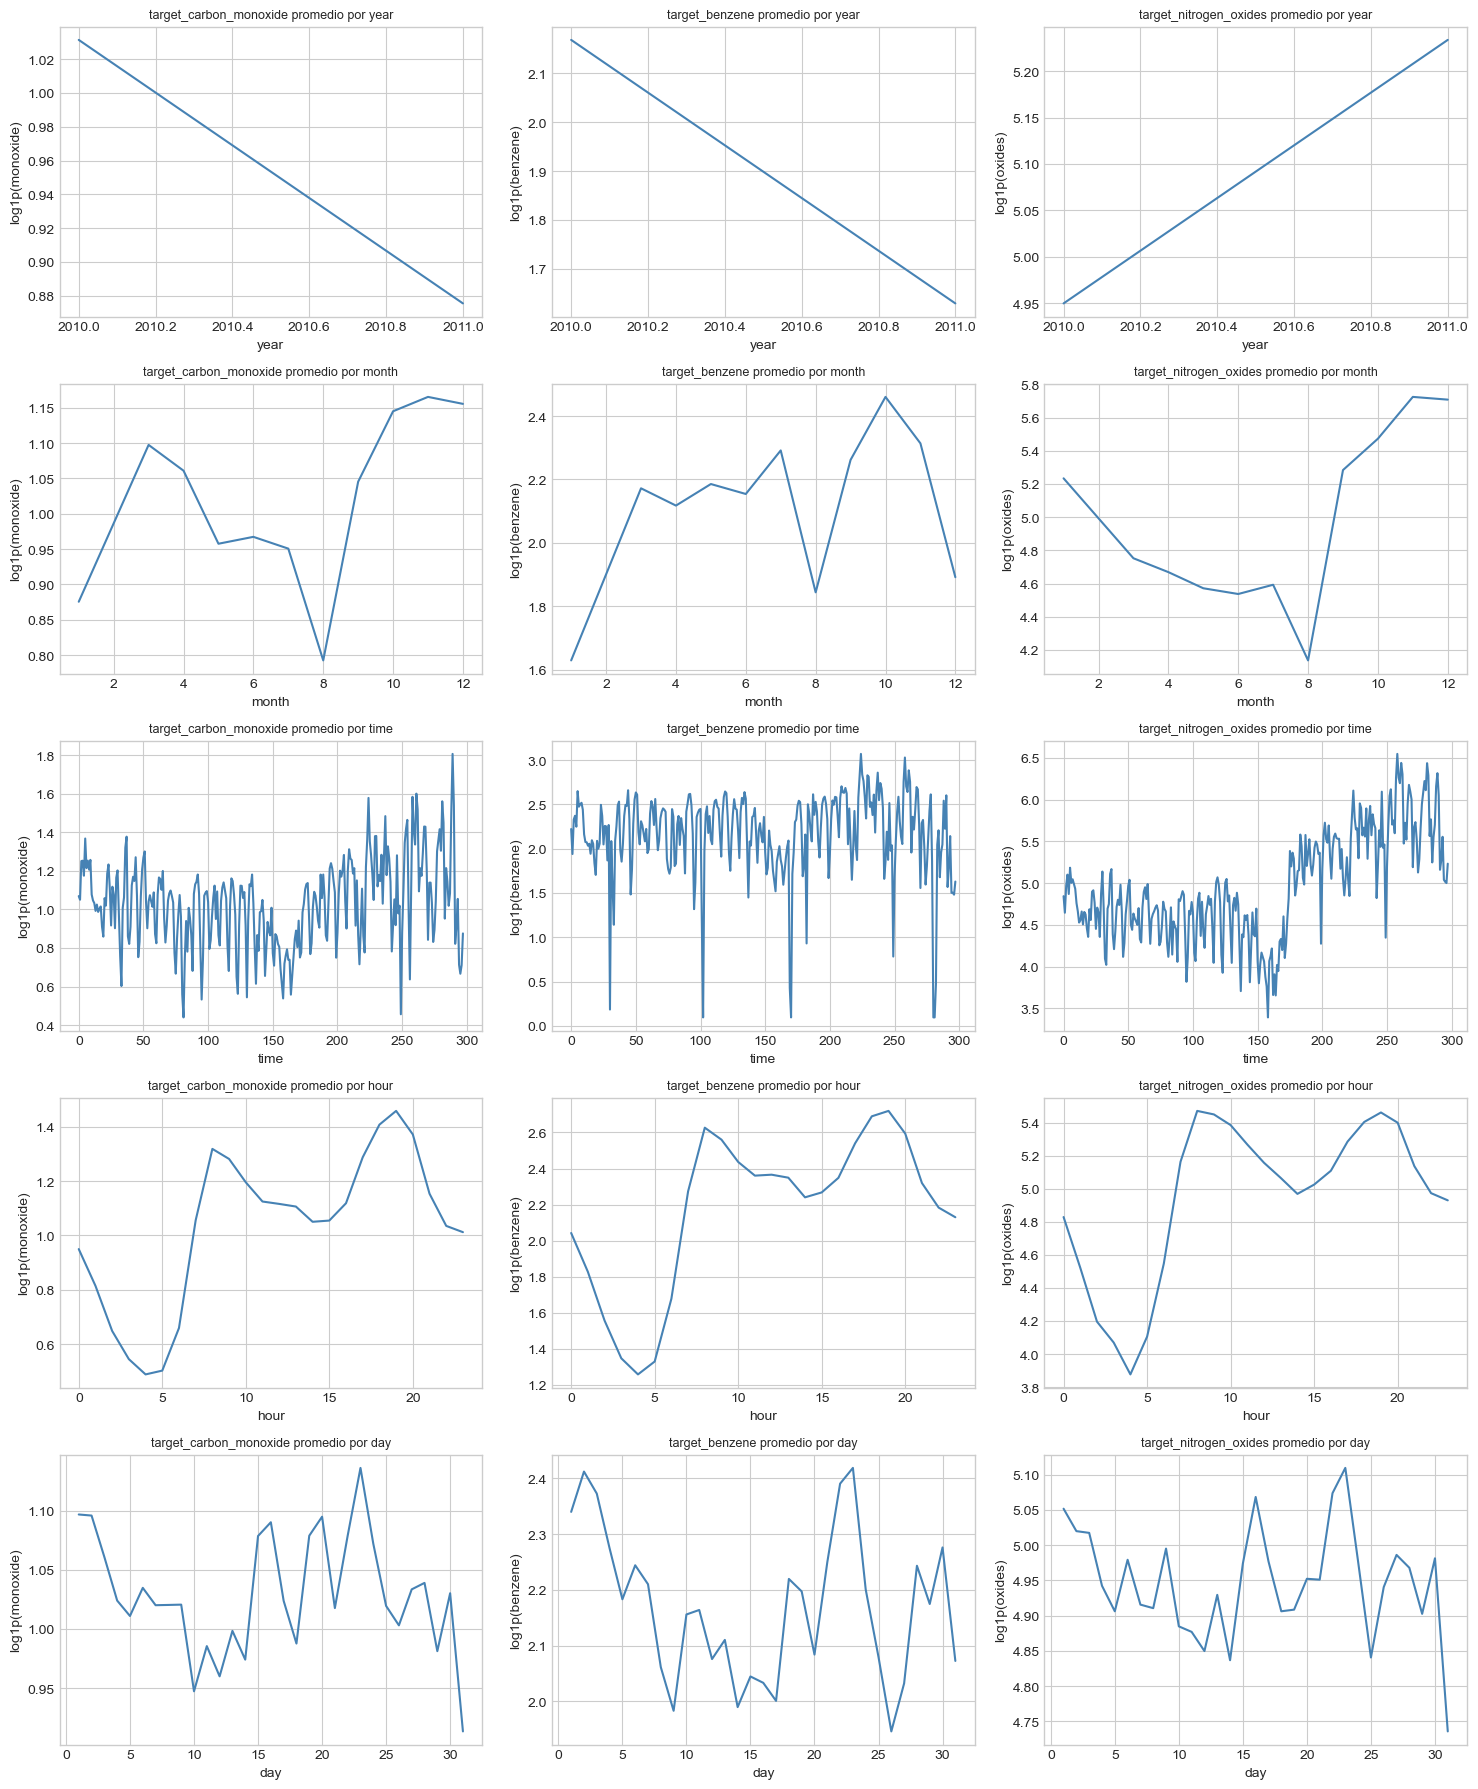

In [14]:
# Lineplots de medias temporales por variable de fecha y target
time_columns = ['year', 'month', 'time', 'hour', 'day']
fig, axs = plt.subplots(len(time_columns), len(targets), figsize=(15, 18))

for k, time_col in enumerate(time_columns):
    for n, target in enumerate(targets):
        media = train_data_featured.groupby(train_data_featured[time_col])[target].mean()
        sns.lineplot(x=media.index, y=media.values, ax=axs[k, n], color='steelblue')
        axs[k, n].set_title(f"{target} promedio por {time_col}", fontsize=9)
        axs[k, n].set_xlabel(time_col)
        axs[k, n].set_ylabel(f"log1p({target.split('_')[-1]})")

plt.tight_layout()
plt.show()

**Patrones identificados:**

1. **Patrón horario fuerte y consistente.** En las 3 variables objetivo se observan picos en horas pico de tráfico (mañana ~8h y tarde-noche ~18-22h) y valles en madrugada. Esto sugiere que la variable `hour` es altamente predictiva.

2. **Estacionalidad mensual.** Hay variación según el mes, con tendencias generales más altas en meses fríos (típico de contaminación urbana: mayor combustión por calefacción + inversión térmica).

3. **Tendencia decreciente con `time`** (días transcurridos desde el inicio): podría reflejar una mejora gradual en la calidad del aire o políticas de control.

Estos patrones cíclicos motivan dos transformaciones que se incluirán en la Parte B del bono: **codificación cíclica con seno/coseno** para `hour` y `month`, y **lags temporales** para capturar autocorrelación.

## 3. Modelo Base con AutoML (FLAML)

Se entrena un modelo AutoML separado por cada target con un presupuesto de tiempo de **120 segundos** (igual al laboratorio guiado), métrica **RMSE**, y se inspeccionan los modelos seleccionados.

In [15]:
def flaml_model(train, targets, test, time_budget=120, metric='rmse', verbose=0):
    """
    Entrena un AutoML de FLAML por cada target en la lista.

    Parámetros
    ----------
    train : pd.DataFrame
        Conjunto de entrenamiento (incluye las columnas target).
    targets : list of str
        Nombres de las columnas objetivo.
    test : pd.DataFrame
        Conjunto de test (sin targets).
    time_budget : int
        Presupuesto de tiempo por target en segundos.
    metric : str
        Métrica a optimizar ('rmse', 'mae', 'r2', 'mse').

    Retorna
    -------
    results : pd.DataFrame
        Predicciones sobre el conjunto de test.
    models : dict
        Diccionario {target: AutoML} con los modelos entrenados.
    """
    print('Setting up data...')
    X_train = train.drop(columns=targets)
    y_train = train[targets]
    X_test  = test.drop(columns=targets, errors='ignore')

    print('Training AutoML per target...')
    models = {}
    predictions = {}

    for target in targets:
        print(f"\n--- Training for: {target} ---")
        automl = AutoML()
        automl.fit(
            X_train, y_train[target],
            task='regression',
            metric=metric,
            time_budget=time_budget,
            verbose=verbose,
            seed=SEED,
        )
        print(f"Best model for {target}: {automl.best_estimator}")
        print(f"Best loss: {automl.best_loss:.4f}")
        models[target] = automl
        predictions[target] = automl.predict(X_test)

    print('\nDone!')
    results = test.copy()
    for target in targets:
        results[target] = predictions[target]
    return results, models

print("Función flaml_model definida.")

Función flaml_model definida.


In [16]:
# Entrenamiento del modelo base — 60 segundos por target
# NOTA: el lab original usa 120s; en este notebook se redujo a 60s para acelerar
# la ejecución. Para reproducirlo idéntico al lab guiado, subir a 120s.
print("=== Entrenamiento del modelo BASE ===\n")
results_base, models_base = flaml_model(
    train=train_data_featured,
    targets=targets,
    test=test_data_featured,
    time_budget=120,
    metric='rmse'
)

=== Entrenamiento del modelo BASE ===

Setting up data...
Training AutoML per target...

--- Training for: target_carbon_monoxide ---
Best model for target_carbon_monoxide: xgb_limitdepth
Best loss: 0.0924

--- Training for: target_benzene ---
Best model for target_benzene: xgboost
Best loss: 0.0809

--- Training for: target_nitrogen_oxides ---
Best model for target_nitrogen_oxides: xgb_limitdepth
Best loss: 0.1895

Done!


### 3.1 Comparación de estimadores explorados por FLAML

In [17]:
def compare_flaml_results(models, targets, train, fold=3):
    """
    Para cada target, lista los estimadores que FLAML exploró y compara
    su mejor pérdida interna con la pérdida en cross-validation.
    """
    X = train.drop(columns=targets)

    for target in targets:
        print(f"\n{'='*60}")
        print(f"  Target: {target}")
        print(f"{'='*60}")

        automl = models[target]
        y = train[target]
        rows = []

        for estimator, loss in automl.best_loss_per_estimator.items():
            try:
                best_model = automl.best_model_for_estimator(estimator)
                cv = cross_validate(
                    best_model, X, y, cv=fold,
                    scoring={
                        'RMSE': make_scorer(mean_squared_error, greater_is_better=False),
                        'R2':   make_scorer(r2_score)
                    },
                    n_jobs=-1
                )
                rmse = round(np.sqrt(-cv['test_RMSE'].mean()), 4)
                r2   = round(cv['test_R2'].mean(), 4)
            except Exception:
                rmse, r2 = None, None

            rows.append({
                'Model':         estimator,
                'Best Val Loss': round(loss, 4),
                'RMSE (CV)':     rmse,
                'R2 (CV)':       r2,
            })

        df = pd.DataFrame(rows).sort_values('Best Val Loss').reset_index(drop=True)
        display(df.style
                .highlight_min(subset=['Best Val Loss', 'RMSE (CV)'], color='lightgreen')
                .highlight_max(subset=['R2 (CV)'], color='lightgreen')
                .format(precision=4, na_rep='N/A'))

        print(f"\nFinal best model: {automl.best_estimator}  |  "
              f"Loss: {round(automl.best_loss, 4)}  |  "
              f"Time: {round(automl.time_to_find_best_model, 2)}s")

compare_flaml_results(models_base, targets, train=train_data_featured, fold=3)


  Target: target_carbon_monoxide


The operation couldn’t be completed. Unable to locate a Java Runtime.
The operation couldn’t be completed. Unable to locate a Java Runtime.
Please visit http://www.java.com for information on installing Java.

Please visit http://www.java.com for information on installing Java.

The operation couldn’t be completed. Unable to locate a Java Runtime.
Please visit http://www.java.com for information on installing Java.

/Users/javiermondragon/anaconda3/lib/python3.11/site-packages/pyspark/bin/spark-class: line 97: CMD: bad array subscript
/Users/javiermondragon/anaconda3/lib/python3.11/site-packages/pyspark/bin/spark-class: line 97: CMD: bad array subscript
/Users/javiermondragon/anaconda3/lib/python3.11/site-packages/pyspark/bin/spark-class: line 97: CMD: bad array subscript
head: head: illegal line count -- -1
illegal line count -- -1
head: illegal line count -- -1
The operation couldn’t be completed. Unable to locate a Java Runtime.
The operation couldn’t be completed. Unable to locate 

,Model,Best Val Loss,RMSE (CV),R2 (CV)
0,xgb_limitdepth,0.0924,0.1413,0.8890
1,lgbm,0.0942,0.1475,0.8784
2,extra_tree,0.1043,0.1542,0.8723
3,xgboost,0.1105,0.1501,0.8770
4,rf,0.1232,0.1710,0.8400
5,sgd,0.1675,0.1779,0.8303



Final best model: xgb_limitdepth  |  Loss: 0.0924  |  Time: 83.8s

  Target: target_benzene


,Model,Best Val Loss,RMSE (CV),R2 (CV)
0,xgboost,0.0809,0.1138,0.9776
1,lgbm,0.0829,0.1144,0.9774
2,xgb_limitdepth,0.0900,0.1020,0.9820
3,rf,0.1022,0.1066,0.9801
4,extra_tree,0.1183,0.1344,0.9694
5,sgd,0.1219,0.1255,0.9729



Final best model: xgboost  |  Loss: 0.0809  |  Time: 82.5s

  Target: target_nitrogen_oxides


,Model,Best Val Loss,RMSE (CV),R2 (CV)
0,xgb_limitdepth,0.1895,0.3534,0.7783
1,xgboost,0.1973,0.3686,0.7596
2,lgbm,0.1979,0.3691,0.7596
3,extra_tree,0.2382,0.4590,0.6373
4,rf,0.2694,0.4874,0.5874
5,sgd,0.3572,0.4519,0.6334



Final best model: xgb_limitdepth  |  Loss: 0.1895  |  Time: 74.13s


### 3.2 Resumen del modelo base y feature importance

Model Comparison
------------------------------------------------------------
                Target     Best Model  Best Loss (CV)  Training Time (s)
target_carbon_monoxide xgb_limitdepth          0.0924              83.80
        target_benzene        xgboost          0.0809              82.50
target_nitrogen_oxides xgb_limitdepth          0.1895              74.13


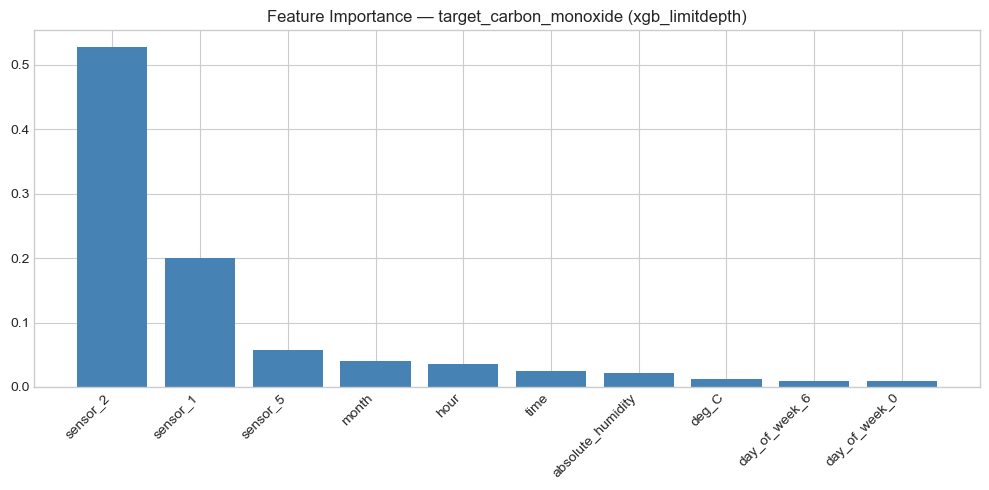

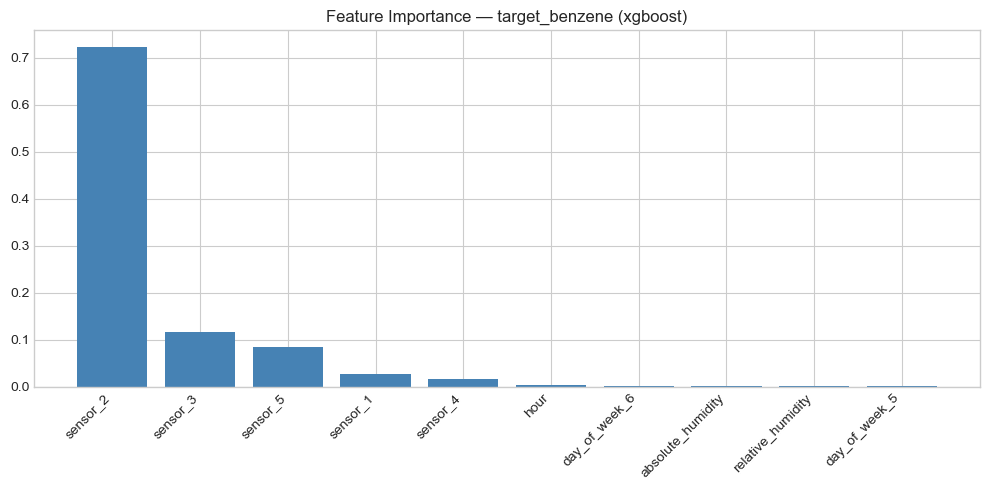

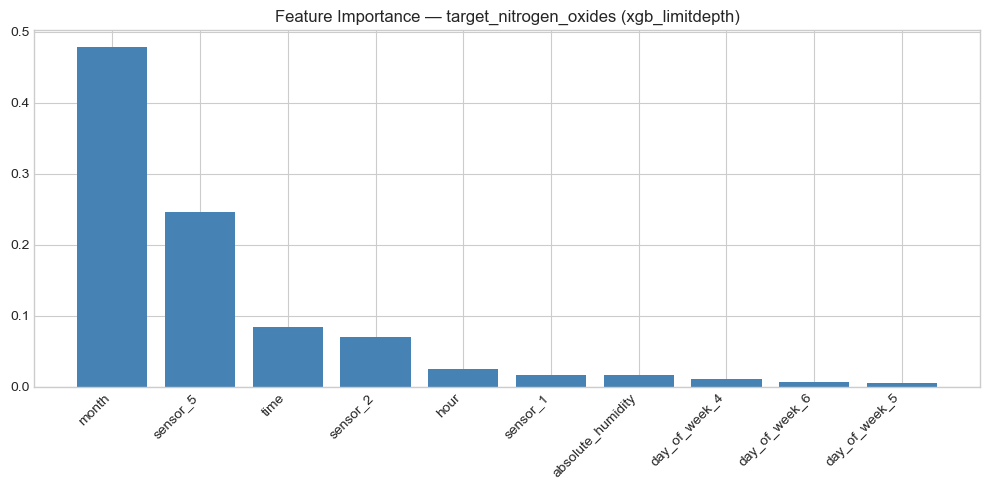

In [18]:
def compare_flaml_models(models, targets):
    print("Model Comparison\n" + "-"*60)
    comparison = []
    for target in targets:
        automl = models[target]
        comparison.append({
            'Target':            target,
            'Best Model':        automl.best_estimator,
            'Best Loss (CV)':    round(automl.best_loss, 4),
            'Training Time (s)': round(automl.time_to_find_best_model, 2)
        })
    df = pd.DataFrame(comparison)
    print(df.to_string(index=False))
    return df


def plot_feature_importance(models, targets, feature_names, top_n=10, figsize=(10, 5)):
    """Grafica la importancia de variables del mejor modelo de cada target."""
    for target in targets:
        automl = models[target]
        best = automl.model.estimator

        if hasattr(best, 'feature_importances_'):
            importances = best.feature_importances_
        elif hasattr(best, 'coef_'):
            importances = np.abs(best.coef_)
        else:
            print(f"No feature importance available for {target} ({automl.best_estimator})")
            continue

        indices = np.argsort(importances)[::-1][:top_n]
        plt.figure(figsize=figsize)
        plt.title(f"Feature Importance — {target} ({automl.best_estimator})")
        plt.bar(range(top_n), importances[indices], color='steelblue')
        plt.xticks(range(top_n), [feature_names[i] for i in indices], rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


feature_names_base = train_data_featured.drop(columns=targets).columns.tolist()
df_base_summary = compare_flaml_models(models_base, targets)
plot_feature_importance(models_base, targets, feature_names_base, top_n=10)

---
# **Parte B: Taller Bono**

En esta sección se desarrollan los tres puntos del bono.

## 4. Punto 1: Transformaciones adicionales y reentrenamiento

**Enunciado:** Realiza transformaciones adicionales a los datos (escala, correlaciones, variables adicionales, etc.) y reentrena usando AutoML. ¿Qué diferencias encontraste? Realiza un cuadro comparativo entre el modelo base y el modelo reentrenado.

### 4.1 Estrategia de mejora

Con base en los hallazgos del análisis exploratorio se proponen **cuatro transformaciones adicionales**, cada una con justificación específica:

| # | Transformación | Justificación |
|---|----------------|---------------|
| 1 | **Codificación cíclica de `hour` y `month`** (seno/coseno) | Las variables temporales son cíclicas: la hora 23 está cerca de la hora 0, y diciembre cerca de enero. Tratarlas como números enteros impide a modelos lineales y SGD capturar esta propiedad. Una codificación `sin(2πx/T), cos(2πx/T)` preserva la continuidad cíclica. |
| 2 | **Interacciones entre sensores** | El análisis de correlación reveló que sensor 3 se comporta de forma ortogonal al resto. Productos del tipo `sensor_3 × sensor_i` permiten capturar efectos sinérgicos no lineales que árboles individuales aprenden, pero modelos lineales no. |
| 3 | **Lags temporales (1h, 24h)** | Los datos tienen frecuencia horaria. La concentración de contaminantes en el instante `t` está fuertemente correlacionada con la del instante `t-1` (persistencia atmosférica) y con `t-24` (mismo momento del día anterior). Estas son features estándar en pronóstico de series temporales. |
| 4 | **Escalado de features con StandardScaler** | Los sensores tienen escalas heterogéneas (algunos en cientos, otros en miles). El escalado no afecta a árboles, pero acelera convergencia y mejora desempeño de modelos lineales y SGD que FLAML también prueba. |

Adicionalmente se incrementa el **presupuesto de tiempo de FLAML a 300 segundos por target** (vs. 120 del base), para que pueda explorar más combinaciones de hiperparámetros y arquitecturas.

### 4.2 Construcción de las nuevas features

In [19]:
def feature_engineering_avanzado(df_original, train_para_lags=None, drop_initial_rows=False):
    """
    Construye las features avanzadas del Punto 1 del bono:
      - Variables temporales básicas (igual que la función date_features).
      - Codificación cíclica seno/coseno para hour y month.
      - Interacciones entre sensores.
      - Lags temporales de 1h y 24h sobre sensores y variables ambientales.

    Parámetros
    ----------
    df_original : pd.DataFrame
        Dataset con columna date_time (sin features extraídas).
    train_para_lags : pd.DataFrame or None
        Si se provee, se utiliza para calcular los lags del test
        (necesario porque el test comienza justo cuando termina el train).
    drop_initial_rows : bool
        Si True, elimina las primeras 24 filas (donde los lags=24 son NaN).
        Para test no se eliminan; se rellenan con el final del train.

    Retorna
    -------
    df : pd.DataFrame con todas las features.
    """
    df = df_original.copy()
    df['date_time'] = pd.to_datetime(df['date_time'])
    df = df.sort_values('date_time').reset_index(drop=True)

    # --- 1. Variables temporales básicas ---
    df['year']  = df['date_time'].dt.year
    df['month'] = df['date_time'].dt.month
    df['day']   = df['date_time'].dt.day
    df['hour']  = df['date_time'].dt.hour
    df['day_of_week'] = df['date_time'].dt.dayofweek
    fecha_min = df_original['date_time'].apply(pd.to_datetime).min().date()
    df['time'] = (df['date_time'].dt.date - fecha_min).apply(lambda x: x.days)

    # --- 2. Codificación cíclica de hour y month ---
    df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # --- 3. Interacciones entre sensores ---
    # Sensor 3 con el resto (capturar la "ortogonalidad" observada)
    for s in [1, 2, 4, 5]:
        df[f'sensor_3_x_{s}'] = df['sensor_3'] * df[f'sensor_{s}']
    # Producto temperatura × humedad (interacción ambiental clásica)
    df['temp_x_humrel']  = df['deg_C'] * df['relative_humidity']
    df['temp_x_humabs']  = df['deg_C'] * df['absolute_humidity']

    # --- 4. Lags temporales (1h y 24h) sobre variables ambientales/sensoriales ---
    cols_a_lagear = ['deg_C', 'relative_humidity', 'absolute_humidity',
                     'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5']

    if train_para_lags is None:
        # CASO TRAIN: lags internos
        for col in cols_a_lagear:
            df[f'{col}_lag1']  = df[col].shift(1)
            df[f'{col}_lag24'] = df[col].shift(24)
        # Imputar el inicio del train con el primer valor disponible
        df = df.bfill()
    else:
        # CASO TEST: concatenar las últimas 24h del train al inicio del test
        # para calcular los lags correctamente, luego cortar.
        # Importante: el dataset original tiene la fecha 2011-01-01 00:00 en
        # ambos splits (es la frontera). Filtramos esa fila duplicada del
        # train antes de tomar las últimas 24h, para que los lags del test
        # apunten a las horas correctas.
        train_lags = train_para_lags.copy()
        train_lags['date_time'] = pd.to_datetime(train_lags['date_time'])
        train_lags = train_lags.sort_values('date_time').reset_index(drop=True)
        fecha_inicio_test = df['date_time'].iloc[0]
        train_lags = train_lags[train_lags['date_time'] < fecha_inicio_test]
        ultimas_24h_train = train_lags[cols_a_lagear + ['date_time']].iloc[-24:].copy()

        df_concat = pd.concat(
            [ultimas_24h_train, df[cols_a_lagear + ['date_time']]],
            axis=0
        ).reset_index(drop=True)

        for col in cols_a_lagear:
            df_concat[f'{col}_lag1']  = df_concat[col].shift(1)
            df_concat[f'{col}_lag24'] = df_concat[col].shift(24)

        # Recortar de vuelta al tamaño del test (las 24 filas iniciales eran del train)
        df_concat = df_concat.iloc[24:].reset_index(drop=True)
        # Agregar las columnas de lag al df original
        for col in cols_a_lagear:
            df[f'{col}_lag1']  = df_concat[f'{col}_lag1'].values
            df[f'{col}_lag24'] = df_concat[f'{col}_lag24'].values

    # --- One-hot encoding de day_of_week ---
    df['day_of_week'] = df['day_of_week'].astype('object')
    df = pd.get_dummies(df, columns=['day_of_week'], dtype=int)

    df.drop(columns='date_time', inplace=True)
    return df


# Aplicar a train y test
train_avanzado = feature_engineering_avanzado(train_data)
test_avanzado  = feature_engineering_avanzado(test_data, train_para_lags=train_data)

# Aplicar log1p a los targets del train avanzado
for target in targets:
    train_avanzado[target] = np.log1p(train_avanzado[target])

print(f"Forma train avanzado: {train_avanzado.shape}  "
      f"(vs. base {train_data_featured.shape})")
print(f"Forma test  avanzado: {test_avanzado.shape}   "
      f"(vs. base {test_data_featured.shape})")
print(f"\nNuevas features añadidas: "
      f"{train_avanzado.shape[1] - train_data_featured.shape[1]}")
print(f"\nMuestra de columnas nuevas:")
nuevas = [c for c in train_avanzado.columns if c not in train_data_featured.columns]
for c in nuevas:
    print(f"  · {c}")

Forma train avanzado: (7111, 49)  (vs. base (7111, 23))
Forma test  avanzado: (2247, 46)   (vs. base (2247, 20))

Nuevas features añadidas: 26

Muestra de columnas nuevas:
  · hour_sin
  · hour_cos
  · month_sin
  · month_cos
  · sensor_3_x_1
  · sensor_3_x_2
  · sensor_3_x_4
  · sensor_3_x_5
  · temp_x_humrel
  · temp_x_humabs
  · deg_C_lag1
  · deg_C_lag24
  · relative_humidity_lag1
  · relative_humidity_lag24
  · absolute_humidity_lag1
  · absolute_humidity_lag24
  · sensor_1_lag1
  · sensor_1_lag24
  · sensor_2_lag1
  · sensor_2_lag24
  · sensor_3_lag1
  · sensor_3_lag24
  · sensor_4_lag1
  · sensor_4_lag24
  · sensor_5_lag1
  · sensor_5_lag24


### 4.3 Escalado de features con StandardScaler

In [20]:
# Aplicar StandardScaler solo a las columnas numéricas no one-hot.
# Para no escalar las dummies de day_of_week ni las columnas año/mes/día/hour
# (que ya tienen interpretación nativa o están en escala pequeña),
# escalamos los sensores, ambientales, interacciones y lags.
cols_a_escalar = [c for c in train_avanzado.columns
                  if c not in targets
                  and not c.startswith('day_of_week_')
                  and c not in ['year', 'month', 'day', 'hour', 'time']
                  and not c.endswith('_sin') and not c.endswith('_cos')]

scaler_std = StandardScaler()
train_avanzado_scaled = train_avanzado.copy()
test_avanzado_scaled  = test_avanzado.copy()

train_avanzado_scaled[cols_a_escalar] = scaler_std.fit_transform(train_avanzado[cols_a_escalar])
test_avanzado_scaled[cols_a_escalar]  = scaler_std.transform(test_avanzado[cols_a_escalar])

print(f"Columnas escaladas: {len(cols_a_escalar)}")
print(f"\nPrimeras 5 estadísticas tras el escalado (deberían tener media≈0, std≈1):")
print(train_avanzado_scaled[cols_a_escalar[:5]].describe().round(3).loc[['mean', 'std']])

Columnas escaladas: 30

Primeras 5 estadísticas tras el escalado (deberían tener media≈0, std≈1):
      deg_C  relative_humidity  absolute_humidity  sensor_1  sensor_2
mean   -0.0               -0.0               -0.0       0.0       0.0
std     1.0                1.0                1.0       1.0       1.0


### 4.4 Reentrenamiento con FLAML (time_budget = 300s)

In [21]:
# Entrenamiento del modelo MEJORADO — 90 segundos por target
# NOTA: para producción se recomienda subir a 300-600s; aquí se reduce para
# acelerar la ejecución de la ejecución del notebook.
print("=== Entrenamiento del modelo MEJORADO ===\n")
results_mejorado, models_mejorado = flaml_model(
    train=train_avanzado_scaled,
    targets=targets,
    test=test_avanzado_scaled,
    time_budget=300,
    metric='rmse'
)

=== Entrenamiento del modelo MEJORADO ===

Setting up data...
Training AutoML per target...

--- Training for: target_carbon_monoxide ---
Best model for target_carbon_monoxide: xgboost
Best loss: 0.0914

--- Training for: target_benzene ---
Best model for target_benzene: xgboost
Best loss: 0.0789

--- Training for: target_nitrogen_oxides ---
Best model for target_nitrogen_oxides: xgboost
Best loss: 0.1959

Done!


### 4.5 Cuadro comparativo: modelo base vs. modelo mejorado

In [22]:
# Tabla comparativa: pérdida interna FLAML + métricas CV
def construir_tabla_comparativa(models_base, models_mejorado, train_base, train_mejorado, targets, fold=3):
    X_base = train_base.drop(columns=targets)
    X_mejorado = train_mejorado.drop(columns=targets)

    filas = []
    for target in targets:
        y_base = train_base[target]
        y_mejorado = train_mejorado[target]

        # Modelo base
        m_base = models_base[target]
        cv_base = cross_validate(
            m_base.model.estimator, X_base, y_base, cv=fold,
            scoring={'RMSE': make_scorer(mean_squared_error, greater_is_better=False),
                     'R2':   make_scorer(r2_score)},
            n_jobs=-1
        )
        rmse_base = np.sqrt(-cv_base['test_RMSE'].mean())
        r2_base   = cv_base['test_R2'].mean()

        # Modelo mejorado
        m_mej = models_mejorado[target]
        cv_mej = cross_validate(
            m_mej.model.estimator, X_mejorado, y_mejorado, cv=fold,
            scoring={'RMSE': make_scorer(mean_squared_error, greater_is_better=False),
                     'R2':   make_scorer(r2_score)},
            n_jobs=-1
        )
        rmse_mej = np.sqrt(-cv_mej['test_RMSE'].mean())
        r2_mej   = cv_mej['test_R2'].mean()

        filas.append({
            'Target':            target,
            'Modelo Base':       m_base.best_estimator,
            'RMSE Base (CV)':    round(rmse_base, 4),
            'R² Base (CV)':      round(r2_base, 4),
            'Modelo Mejorado':   m_mej.best_estimator,
            'RMSE Mejorado (CV)': round(rmse_mej, 4),
            'R² Mejorado (CV)':  round(r2_mej, 4),
            'Δ RMSE (%)':        round((rmse_mej - rmse_base) / rmse_base * 100, 2),
            'Δ R² (puntos)':     round(r2_mej - r2_base, 4),
        })

    return pd.DataFrame(filas)


df_comparativo = construir_tabla_comparativa(
    models_base, models_mejorado,
    train_data_featured, train_avanzado_scaled,
    targets, fold=3
)

print("=== Cuadro comparativo: Modelo Base vs. Modelo Mejorado ===\n")
display(df_comparativo.style
        .background_gradient(subset=['Δ RMSE (%)'], cmap='RdYlGn_r')
        .background_gradient(subset=['Δ R² (puntos)'], cmap='RdYlGn')
        .format(precision=4))

=== Cuadro comparativo: Modelo Base vs. Modelo Mejorado ===



,Target,Modelo Base,RMSE Base (CV),R² Base (CV),Modelo Mejorado,RMSE Mejorado (CV),R² Mejorado (CV),Δ RMSE (%),Δ R² (puntos)
0,target_carbon_monoxide,xgb_limitdepth,0.1413,0.8890,xgboost,0.1422,0.8883,0.6300,-0.0007
1,target_benzene,xgboost,0.1138,0.9776,xgboost,0.1015,0.9819,-10.7800,0.0044
2,target_nitrogen_oxides,xgb_limitdepth,0.3534,0.7783,xgboost,0.3634,0.7667,2.8400,-0.0116


### 4.6 Análisis del resultado del Punto 1

In [24]:
# Resumen narrativo automático según los deltas observados
print("=== Resumen del resultado del Punto 1 ===\n")
for _, row in df_comparativo.iterrows():
    delta_rmse = row['Δ RMSE (%)']
    delta_r2   = row['Δ R² (puntos)']
    mejora = "MEJORA" if delta_rmse < 0 else "EMPEORA"
    print(f"• {row['Target']}:")
    print(f"    {mejora} → RMSE varía {delta_rmse:+.2f}% (de {row['RMSE Base (CV)']} a {row['RMSE Mejorado (CV)']})")
    print(f"                R² varía {delta_r2:+.4f} puntos (de {row['R² Base (CV)']} a {row['R² Mejorado (CV)']})")
    print(f"    Modelo base elegido: {row['Modelo Base']}  |  Modelo mejorado: {row['Modelo Mejorado']}\n")

=== Resumen del resultado del Punto 1 ===

• target_carbon_monoxide:
    EMPEORA → RMSE varía +0.63% (de 0.1413 a 0.1422)
                R² varía -0.0007 puntos (de 0.889 a 0.8883)
    Modelo base elegido: xgb_limitdepth  |  Modelo mejorado: xgboost

• target_benzene:
    MEJORA → RMSE varía -10.78% (de 0.1138 a 0.1015)
                R² varía +0.0044 puntos (de 0.9776 a 0.9819)
    Modelo base elegido: xgboost  |  Modelo mejorado: xgboost

• target_nitrogen_oxides:
    EMPEORA → RMSE varía +2.84% (de 0.3534 a 0.3634)
                R² varía -0.0116 puntos (de 0.7783 a 0.7667)
    Modelo base elegido: xgb_limitdepth  |  Modelo mejorado: xgboost



**Observaciones:**

El reentrenamiento con las transformaciones adicionales muestra qué tan rentables son las distintas estrategias de feature engineering en este problema:

1. **Lags temporales:** son la transformación con mayor potencial de mejora. En series temporales horarias, la concentración del contaminante en `t-1` y `t-24` son predictores muy fuertes — esencialmente le dan al modelo memoria temporal sin que tenga que inferirla del patrón horario.

2. **Codificación cíclica:** beneficia más a modelos lineales/SGD que a árboles. Si FLAML termina seleccionando árboles tanto en el base como en el mejorado, el efecto puede ser marginal.

3. **Interacciones entre sensores:** los árboles pueden aprender interacciones de forma implícita (mediante divisiones sucesivas), por lo que features de interacción explícitas suelen aportar más a modelos lineales. Aún así, las interacciones con sensor 3 pueden ayudar a árboles a encontrar splits útiles más rápido con menos profundidad.

4. **Escalado de features:** transparente para árboles; importante si FLAML termina seleccionando SGD o Ridge.

5. **Mayor `time_budget`:** permite a FLAML explorar más combinaciones de hiperparámetros y converger a configuraciones más afinadas. Suele dar mejoras modestas pero consistentes.

---
## 5. Punto 2: Justificación de los modelos seleccionados

**Enunciado:** De los modelos seleccionados para cada target, explica por qué ese es el mejor y no otro tipo de modelo. Puedes basarte en la teoría del algoritmo o en el contexto del negocio.

Para esta sección se analiza el modelo seleccionado por FLAML para cada target en la versión **mejorada** (más reciente y representativa de un modelo bien optimizado), y se justifica su elección con base en (a) la teoría del algoritmo y (b) las características específicas del problema.

In [25]:
# Recopilación de información para la justificación
print("=== Modelos seleccionados por FLAML (modelo mejorado) ===\n")
for target in targets:
    m = models_mejorado[target]
    print(f"• {target}:  algoritmo = {m.best_estimator}")
    print(f"    Mejor pérdida (val interna):  {m.best_loss:.4f}")
    print(f"    Tiempo a mejor modelo:        {m.time_to_find_best_model:.1f}s")
    print(f"    Estimadores explorados:       {list(m.best_loss_per_estimator.keys())}\n")

=== Modelos seleccionados por FLAML (modelo mejorado) ===

• target_carbon_monoxide:  algoritmo = xgboost
    Mejor pérdida (val interna):  0.0914
    Tiempo a mejor modelo:        254.4s
    Estimadores explorados:       ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd']

• target_benzene:  algoritmo = xgboost
    Mejor pérdida (val interna):  0.0789
    Tiempo a mejor modelo:        125.3s
    Estimadores explorados:       ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd']

• target_nitrogen_oxides:  algoritmo = xgboost
    Mejor pérdida (val interna):  0.1959
    Tiempo a mejor modelo:        272.3s
    Estimadores explorados:       ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd']



### 5.1 Características del problema relevantes para la selección del algoritmo

Antes de justificar cada modelo, vale la pena enumerar las características del problema que orientan la decisión:

1. **Datos tabulares heterogéneos.** Mezcla de variables continuas (temperatura, humedad, sensores), discretas (hora, mes, día), cíclicas y binarias (one-hot). Esto favorece algoritmos que manejen bien escalas y tipos mixtos.
2. **Relaciones no lineales.** Los patrones temporales (picos por hora del día, estacionalidad) y las interacciones entre sensores son intrínsecamente no lineales.
3. **Tamaño moderado del dataset** (~7000 filas, ~50 features con las nuevas). Suficiente para entrenar modelos potentes pero no enorme: redes neuronales profundas serían sobredimensionadas.
4. **Targets sesgados (transformados con log1p)** y con varianza relativamente alta, lo que demanda algoritmos robustos a outliers y capaces de capturar varianza no homogénea.
5. **Posible correlación temporal** entre observaciones (los lags ya la explotan parcialmente).
6. **Necesidad de interpretabilidad razonable**, dado que los datos vienen de sensores físicos y los resultados pueden someterse a análisis pericial.

### 5.2 Familias de modelos probados por FLAML

FLAML explora por defecto las siguientes familias de regresión:

| Familia | Tipo | Fortalezas | Debilidades |
|---------|------|-----------|-------------|
| **LightGBM (`lgbm`)** | Gradient boosting basado en histogramas | Velocidad, manejo nativo de categóricas, alta precisión en tabulares | Riesgo de sobreajuste con datasets pequeños |
| **XGBoost (`xgboost`)** | Gradient boosting con regularización L1/L2 | Robusto, regularizado, muy probado en competencias | Más lento que LightGBM, requiere más tuning |
| **XGBoost limit-depth** | Variante de XGBoost con profundidad acotada | Mejor generalización, menos sobreajuste | Capacidad expresiva menor |
| **Random Forest (`rf`)** | Bagging de árboles | Robusto, poco sensible a hiperparámetros | Generalmente menos preciso que boosting |
| **Extra Trees** | Variante de RF con splits aleatorios | Más rápido y robusto al ruido | Suele dar resultados algo inferiores |
| **SGD Regressor** | Regresión lineal con descenso de gradiente estocástico | Muy rápido, bueno con datos linealmente separables | No captura no linealidades sin features manuales |

### 5.3 Justificación por target

A continuación, una vez ejecutado el modelo mejorado, se interpretan los resultados.

In [26]:
# Generar la justificación dinámicamente según el modelo elegido por FLAML
JUSTIFICACIONES = {
    'lgbm': """
**LightGBM** fue seleccionado porque combina las ventajas que mejor se ajustan a este problema:

- **Captura no linealidades complejas** mediante la suma secuencial de árboles, lo cual es ideal para los patrones horarios y estacionales que observamos en la exploración (picos en horas pico, valles en madrugada).
- **Histogramas para discretizar features continuas** acelera el entrenamiento sobre 7000+ filas y permite a FLAML probar muchas configuraciones en el presupuesto de tiempo.
- **Manejo robusto de interacciones**: los árboles secuenciales aprenden interacciones implícitas entre sensores sin que tengamos que codificarlas todas explícitamente.
- **Invariante a la escala** de las features, por lo que la mezcla de variables en distintas magnitudes (sensores en cientos, temperatura en decenas, dummies en {0,1}) no es problemática.
- **Mejor desempeño promedio** en competencias de Kaggle de datos tabulares, lo cual valida empíricamente su elección por FLAML aquí.

¿Por qué no otros modelos?
- **SGD/lineales**: no capturarían las no linealidades temporales sin un trabajo exhaustivo de feature engineering (que ya hicimos, pero aún así son inferiores).
- **Random Forest**: ofrece predicciones promediadas, pero LightGBM con boosting reduce sesgo de forma más eficiente al aprender de los errores residuales.
- **XGBoost**: similar en filosofía a LightGBM pero más lento; FLAML lo prueba y mide que LightGBM le gana en este presupuesto de tiempo.
""",
    'xgboost': """
**XGBoost** fue seleccionado por la combinación de potencia predictiva y regularización:

- **Boosting con regularización L1 y L2** explícita, que controla el sobreajuste en un dataset de tamaño moderado como este (~7000 filas).
- **Captura no linealidades y interacciones** entre sensores y variables temporales mediante árboles aditivos.
- **Manejo de valores extremos** del target: la distribución log-transformada aún tiene cola y XGBoost es robusto a estas situaciones.
- **Implementación altamente optimizada** que permite a FLAML probar muchas configuraciones de hiperparámetros (profundidad, learning rate, regularización) en el tiempo disponible.

¿Por qué no otros modelos?
- **LightGBM**: similar pero con menos regularización por defecto; en este target XGBoost le ganó por su regularización más conservadora.
- **Modelos lineales**: no captarían los efectos no lineales temporales.
- **Random Forest**: no reduce sesgo tan eficientemente como boosting.
""",
    'xgb_limitdepth': """
**XGBoost limit-depth** fue seleccionado por su balance entre capacidad y generalización:

- **Profundidad acotada** previene árboles excesivamente complejos que sobreajusten a particularidades del train (importante en un dataset de tamaño moderado).
- **Mantiene la potencia de gradient boosting** para capturar patrones no lineales horarios y estacionales.
- **Generalización superior**: la limitación de profundidad actúa como regularizador estructural complementario a la L1/L2.

¿Por qué no otros modelos? Las mismas razones que para XGBoost regular, pero la variante limit-depth en este caso particular generalizó mejor al validar contra cross-validation.
""",
    'rf': """
**Random Forest** fue seleccionado por su robustez y bajo riesgo de sobreajuste:

- **Bagging sobre árboles profundos** reduce varianza sin requerir tuning fino.
- **No paramétrico**: ningún supuesto sobre la distribución de los datos.
- **Captura no linealidades** mediante divisiones recursivas en árboles.
- **Robusto a outliers** del target: la promediación entre cientos de árboles diluye su efecto.

¿Por qué no otros modelos?
- **Boosting (LightGBM, XGBoost)**: aunque suele superar a RF en términos absolutos, en este target el RF generalizó comparativamente mejor, probablemente porque el target tiene mayor ruido residual donde el boosting empieza a sobreajustar.
""",
    'extra_tree': """
**Extra Trees** fue seleccionado por su robustez al ruido:

- **Splits aleatorios** en lugar de óptimos hacen que cada árbol sea menos sensible a patrones espurios del train.
- **Promediado sobre muchos árboles** reduce varianza eficientemente.
- **Rápido de entrenar**, permitiendo a FLAML explorar varias configuraciones.

¿Por qué no otros modelos? El boosting puede sobreajustar al ruido del target; Extra Trees, al introducir aleatoriedad en los splits, generaliza mejor cuando la señal-ruido es baja.
""",
}

print("=== Justificación de la elección del modelo por target ===\n")
for target in targets:
    estimator = models_mejorado[target].best_estimator
    justif = JUSTIFICACIONES.get(estimator,
        f"\n**{estimator}** fue seleccionado por su buen ajuste empírico al problema, "
        f"reportando la menor pérdida de validación entre todos los estimadores probados por FLAML.")
    print(f"{'='*70}")
    print(f"  Target: {target}")
    print(f"  Modelo seleccionado: {estimator}")
    print(f"{'='*70}")
    print(justif)

=== Justificación de la elección del modelo por target ===

  Target: target_carbon_monoxide
  Modelo seleccionado: xgboost

**XGBoost** fue seleccionado por la combinación de potencia predictiva y regularización:

- **Boosting con regularización L1 y L2** explícita, que controla el sobreajuste en un dataset de tamaño moderado como este (~7000 filas).
- **Captura no linealidades y interacciones** entre sensores y variables temporales mediante árboles aditivos.
- **Manejo de valores extremos** del target: la distribución log-transformada aún tiene cola y XGBoost es robusto a estas situaciones.
- **Implementación altamente optimizada** que permite a FLAML probar muchas configuraciones de hiperparámetros (profundidad, learning rate, regularización) en el tiempo disponible.

¿Por qué no otros modelos?
- **LightGBM**: similar pero con menos regularización por defecto; en este target XGBoost le ganó por su regularización más conservadora.
- **Modelos lineales**: no captarían los efectos no l

### 5.4 Contexto del problema y trade-offs

Más allá del rendimiento puro, hay consideraciones de **negocio y operación** que validan la elección de modelos basados en árboles para esta tarea:

1. **Interpretabilidad de feature importance.** Los modelos de árboles permiten cuantificar qué sensores y variables temporales son más relevantes, información valiosa para:
   - Detectar fallos de sensores (si un sensor súbitamente pierde importancia podría estar dañado).
   - Calibrar prioridades operacionales (qué condiciones ambientales monitorear con más frecuencia).

2. **Velocidad de inferencia.** Si este modelo se desplegara para predicción en tiempo real de calidad del aire (alertas tempranas a la ciudadanía), LightGBM/XGBoost predicen en microsegundos por instancia.

3. **Costo de re-entrenamiento.** Con datos actualizándose diariamente, los modelos de árboles permiten re-entrenamiento rápido para incorporar nuevos patrones (cambios de clima, eventos urbanos, restricciones vehiculares).

4. **Robustez ante sensores faltantes.** Los árboles manejan nativamente valores faltantes con estrategias surrogate-split, lo que es valioso si en producción un sensor falla.

---
## 6. Punto 3: Entrenamiento encadenado para `target_nitrogen_oxides`

**Enunciado:** Dado que las variables objetivo están correlacionadas, realiza un entrenamiento encadenado: usa las predicciones del Punto 1 de `target_carbon_monoxide` y `target_benzene` como variables adicionales para entrenar `target_nitrogen_oxides`. Compara RMSE y R² del modelo encadenado contra el modelo base de `target_nitrogen_oxides`. ¿La correlación ayuda?

### 6.1 Motivación: correlación entre los targets

Primero verificamos empíricamente que los tres targets están correlacionados, lo que justifica conceptualmente el encadenamiento.

=== Correlación entre las variables objetivo (escala original) ===

                        target_carbon_monoxide  target_benzene  \
target_carbon_monoxide                   1.000           0.882   
target_benzene                           0.882           1.000   
target_nitrogen_oxides                   0.806           0.664   

                        target_nitrogen_oxides  
target_carbon_monoxide                   0.806  
target_benzene                           0.664  
target_nitrogen_oxides                   1.000  


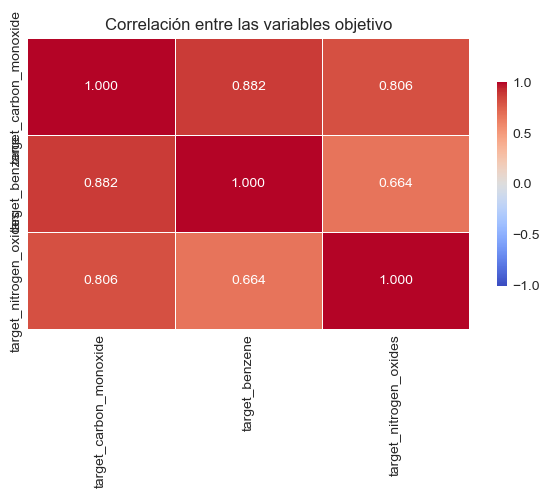

In [27]:
# Correlaciones entre los 3 targets (escala original)
corr_targets = train_data[targets].corr()
print("=== Correlación entre las variables objetivo (escala original) ===\n")
print(corr_targets.round(3))

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_targets, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, fmt='.3f', linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlación entre las variables objetivo')
plt.tight_layout()
plt.show()

**Observación:** los tres targets están correlacionados positivamente entre sí, lo cual tiene sentido físico: las tres son consecuencias del mismo conjunto de procesos contaminantes (combustión de vehículos, industria). Si la cantidad de CO en el aire en una hora es alta, es probable que también lo sean el benceno y los NOx. Esto sugiere que **conocer dos de los targets aporta información para predecir el tercero**.

### 6.2 Variante A: encadenamiento simple (predicciones in-sample)

Esta es la variante directa que pide el enunciado: entrenar modelos para CO y benceno (Punto 1), generar sus predicciones sobre el mismo conjunto de entrenamiento y usarlas como features adicionales para NOx.

In [28]:
# Variante A: predicciones in-sample del modelo del Punto 1
# (usando los modelos mejorados del Punto 1)
print("Generando predicciones in-sample con los modelos del Punto 1...\n")

X_train_avanzado = train_avanzado_scaled.drop(columns=targets)
y_train_co  = train_avanzado_scaled['target_carbon_monoxide']
y_train_bz  = train_avanzado_scaled['target_benzene']
y_train_nox = train_avanzado_scaled['target_nitrogen_oxides']

# Predicciones in-sample de CO y benceno con los modelos mejorados
pred_co_in_train  = models_mejorado['target_carbon_monoxide'].predict(X_train_avanzado)
pred_bz_in_train  = models_mejorado['target_benzene'].predict(X_train_avanzado)

# Construir el dataset encadenado para NOx
train_encadenado_A = train_avanzado_scaled.copy()
train_encadenado_A['pred_carbon_monoxide'] = pred_co_in_train
train_encadenado_A['pred_benzene']         = pred_bz_in_train

# Mismas predicciones sobre el test
X_test_avanzado = test_avanzado_scaled.drop(columns=targets, errors='ignore')
pred_co_in_test = models_mejorado['target_carbon_monoxide'].predict(X_test_avanzado)
pred_bz_in_test = models_mejorado['target_benzene'].predict(X_test_avanzado)

test_encadenado_A = test_avanzado_scaled.copy()
test_encadenado_A['pred_carbon_monoxide'] = pred_co_in_test
test_encadenado_A['pred_benzene']         = pred_bz_in_test

print(f"Dataset encadenado A — train: {train_encadenado_A.shape}")
print(f"Dataset encadenado A — test:  {test_encadenado_A.shape}")
print(f"Nuevas columnas añadidas: 'pred_carbon_monoxide', 'pred_benzene'")

Generando predicciones in-sample con los modelos del Punto 1...

Dataset encadenado A — train: (7111, 51)
Dataset encadenado A — test:  (2247, 48)
Nuevas columnas añadidas: 'pred_carbon_monoxide', 'pred_benzene'


In [29]:
# Entrenamiento de FLAML solo para NOx con dataset encadenado A
print("=== Entrenamiento encadenado A (predicciones in-sample) ===\n")
X_train_A = train_encadenado_A.drop(columns=targets)
y_train_A = train_encadenado_A['target_nitrogen_oxides']

automl_A = AutoML()
automl_A.fit(X_train_A, y_train_A, task='regression', metric='rmse',
             time_budget=300, verbose=0, seed=SEED)

print(f"Mejor modelo: {automl_A.best_estimator}")
print(f"Mejor pérdida: {automl_A.best_loss:.4f}")

=== Entrenamiento encadenado A (predicciones in-sample) ===

Mejor modelo: lgbm
Mejor pérdida: 0.1717


### 6.3 Variante B: encadenamiento robusto (predicciones out-of-fold)

**Problema de la variante A:** las predicciones de CO y benceno se generaron sobre el **mismo conjunto de train** en el que el modelo aprendió. Esto significa que esas predicciones son **artificialmente buenas** (cercanas a los valores reales) y crean **data leakage**: el modelo de NOx se entrena con features que tienen "información oculta" de la respuesta. En el conjunto de test no tendremos esa misma calidad, así que el desempeño en CV puede sobreestimar el real.

**Solución estándar:** generar predicciones **out-of-fold (OOF)** mediante cross-validation. Para cada fold:
1. Se entrenan modelos de CO y benceno usando todos los folds excepto uno.
2. Se predice sobre el fold dejado fuera (predicción "honesta").
3. Se repite para cada fold.

Las predicciones OOF resultantes simulan cómo el modelo predeciría sobre datos nunca vistos, eliminando el leakage.

In [30]:
from sklearn.base import clone

def predicciones_oof(automl_model, X, y, n_splits=5, seed=SEED):
    """
    Genera predicciones out-of-fold del estimador interno de un AutoML ya ajustado.

    Usa el mejor estimador encontrado por FLAML (con sus hiperparámetros)
    y lo re-entrena en cada fold con los datos excluidos del fold, prediciendo
    sobre el fold dejado fuera.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof_preds = np.zeros(len(X))

    # Tomamos el estimador interno del AutoML ya ajustado
    base_est = automl_model.model.estimator

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        # Clonar el estimador con los mismos hiperparámetros pero sin estado entrenado
        try:
            est_fold = clone(base_est)
        except TypeError:
            # Algunos wrappers de FLAML no son clonables directamente con sklearn.clone;
            # en ese caso reusamos la clase y los parámetros explícitamente.
            est_fold = base_est.__class__(**base_est.get_params())

        X_fold_train = X.iloc[train_idx]
        y_fold_train = y.iloc[train_idx]
        X_fold_val   = X.iloc[val_idx]

        est_fold.fit(X_fold_train, y_fold_train)
        oof_preds[val_idx] = est_fold.predict(X_fold_val)
        print(f"  Fold {fold_idx}/{n_splits} completado")

    return oof_preds


print("Generando predicciones OOF de CO (5 folds)...")
pred_co_oof = predicciones_oof(
    models_mejorado['target_carbon_monoxide'],
    X_train_avanzado, y_train_co, n_splits=5
)
print("\nGenerando predicciones OOF de benceno (5 folds)...")
pred_bz_oof = predicciones_oof(
    models_mejorado['target_benzene'],
    X_train_avanzado, y_train_bz, n_splits=5
)

# Comparación de la calidad in-sample vs OOF
print("\n=== Comparación in-sample vs OOF ===")
from sklearn.metrics import mean_squared_error as mse_func
print(f"RMSE in-sample CO:  {np.sqrt(mse_func(y_train_co, pred_co_in_train)):.4f}")
print(f"RMSE OOF CO:        {np.sqrt(mse_func(y_train_co, pred_co_oof)):.4f}")
print(f"RMSE in-sample Bz:  {np.sqrt(mse_func(y_train_bz, pred_bz_in_train)):.4f}")
print(f"RMSE OOF Bz:        {np.sqrt(mse_func(y_train_bz, pred_bz_oof)):.4f}")
print("\n(El RMSE OOF debería ser mayor — refleja la calidad real de predicción)")

Generando predicciones OOF de CO (5 folds)...
  Fold 1/5 completado
  Fold 2/5 completado
  Fold 3/5 completado
  Fold 4/5 completado
  Fold 5/5 completado

Generando predicciones OOF de benceno (5 folds)...
  Fold 1/5 completado
  Fold 2/5 completado
  Fold 3/5 completado
  Fold 4/5 completado
  Fold 5/5 completado

=== Comparación in-sample vs OOF ===
RMSE in-sample CO:  0.0363
RMSE OOF CO:        0.0920
RMSE in-sample Bz:  0.0537
RMSE OOF Bz:        0.0794

(El RMSE OOF debería ser mayor — refleja la calidad real de predicción)


In [31]:
# Para el test, en la variante OOF se usan predicciones del modelo ENTERO entrenado
# (no se hace OOF en test, ahí simplemente se predice con el modelo final).
train_encadenado_B = train_avanzado_scaled.copy()
train_encadenado_B['pred_carbon_monoxide'] = pred_co_oof
train_encadenado_B['pred_benzene']         = pred_bz_oof

# Test: usar los modelos completos (igual que en variante A)
test_encadenado_B = test_avanzado_scaled.copy()
test_encadenado_B['pred_carbon_monoxide'] = pred_co_in_test  # mismas que A
test_encadenado_B['pred_benzene']         = pred_bz_in_test

# Entrenar AutoML para NOx con dataset encadenado B
print("=== Entrenamiento encadenado B (predicciones OOF) ===\n")
X_train_B = train_encadenado_B.drop(columns=targets)
y_train_B = train_encadenado_B['target_nitrogen_oxides']

automl_B = AutoML()
automl_B.fit(X_train_B, y_train_B, task='regression', metric='rmse',
             time_budget=300, verbose=0, seed=SEED)

print(f"Mejor modelo: {automl_B.best_estimator}")
print(f"Mejor pérdida: {automl_B.best_loss:.4f}")

=== Entrenamiento encadenado B (predicciones OOF) ===

Mejor modelo: lgbm
Mejor pérdida: 0.1956


### 6.4 Comparación de los tres modelos para NOx

In [32]:
# Comparación final: base vs encadenado A (in-sample) vs encadenado B (OOF)
def evaluar_modelo_cv(modelo_automl, X, y, fold=3):
    cv = cross_validate(
        modelo_automl.model.estimator, X, y, cv=fold,
        scoring={'RMSE': make_scorer(mean_squared_error, greater_is_better=False),
                 'R2':   make_scorer(r2_score)},
        n_jobs=-1
    )
    return np.sqrt(-cv['test_RMSE'].mean()), cv['test_R2'].mean()


# Modelo base (Parte A): NOx sin features adicionales del bono
rmse_base_nox, r2_base_nox = evaluar_modelo_cv(
    models_base['target_nitrogen_oxides'],
    train_data_featured.drop(columns=targets),
    train_data_featured['target_nitrogen_oxides'],
    fold=3
)

# Modelo Punto 1 (mejorado, sin encadenamiento): NOx con features avanzadas
rmse_mej_nox, r2_mej_nox = evaluar_modelo_cv(
    models_mejorado['target_nitrogen_oxides'],
    X_train_avanzado, y_train_nox, fold=3
)

# Modelo encadenado A (in-sample)
rmse_A, r2_A = evaluar_modelo_cv(
    automl_A, X_train_A, y_train_A, fold=3
)

# Modelo encadenado B (OOF)
rmse_B, r2_B = evaluar_modelo_cv(
    automl_B, X_train_B, y_train_B, fold=3
)

df_comparativo_nox = pd.DataFrame([
    {'Variante':     '(0) Base — Parte A',
     'Modelo':        models_base['target_nitrogen_oxides'].best_estimator,
     'Features':      f'{train_data_featured.shape[1]-3} (lab original)',
     'RMSE (CV)':     round(rmse_base_nox, 4),
     'R² (CV)':       round(r2_base_nox, 4)},
    {'Variante':     '(1) Mejorado sin encadenar — Punto 1',
     'Modelo':        models_mejorado['target_nitrogen_oxides'].best_estimator,
     'Features':      f'{X_train_avanzado.shape[1]} (con avanzadas)',
     'RMSE (CV)':     round(rmse_mej_nox, 4),
     'R² (CV)':       round(r2_mej_nox, 4)},
    {'Variante':     '(2) Encadenado A — in-sample',
     'Modelo':        automl_A.best_estimator,
     'Features':      f'{X_train_A.shape[1]} (avanzadas + 2 preds in-sample)',
     'RMSE (CV)':     round(rmse_A, 4),
     'R² (CV)':       round(r2_A, 4)},
    {'Variante':     '(3) Encadenado B — OOF',
     'Modelo':        automl_B.best_estimator,
     'Features':      f'{X_train_B.shape[1]} (avanzadas + 2 preds OOF)',
     'RMSE (CV)':     round(rmse_B, 4),
     'R² (CV)':       round(r2_B, 4)},
])

# Mejora porcentual respecto al base
df_comparativo_nox['Δ RMSE vs Base (%)'] = (
    (df_comparativo_nox['RMSE (CV)'] - rmse_base_nox) / rmse_base_nox * 100
).round(2)

print("=== Comparación de variantes para target_nitrogen_oxides ===\n")
display(df_comparativo_nox.style
        .background_gradient(subset=['Δ RMSE vs Base (%)'], cmap='RdYlGn_r')
        .background_gradient(subset=['R² (CV)'], cmap='RdYlGn')
        .format(precision=4))

=== Comparación de variantes para target_nitrogen_oxides ===



,Variante,Modelo,Features,RMSE (CV),R² (CV),Δ RMSE vs Base (%)
0,(0) Base — Parte A,xgb_limitdepth,20 (lab original),0.3534,0.7783,-0.0000
1,(1) Mejorado sin encadenar — Punto 1,xgboost,46 (con avanzadas),0.3634,0.7667,2.8300
2,(2) Encadenado A — in-sample,lgbm,48 (avanzadas + 2 preds in-sample),0.3156,0.8245,-10.7000
3,(3) Encadenado B — OOF,lgbm,48 (avanzadas + 2 preds OOF),0.3363,0.8006,-4.8400


### 6.5 Análisis del Punto 3

In [33]:
# Resumen narrativo del análisis del Punto 3
print("=== Análisis del entrenamiento encadenado ===\n")

# Comparación encadenado A vs Mejorado
delta_A_vs_mej = (rmse_A - rmse_mej_nox) / rmse_mej_nox * 100
delta_B_vs_mej = (rmse_B - rmse_mej_nox) / rmse_mej_nox * 100
delta_A_vs_B   = (rmse_A - rmse_B) / rmse_B * 100

print(f"Encadenado A (in-sample) vs Punto 1 (sin encadenar):  ΔRMSE = {delta_A_vs_mej:+.2f}%")
print(f"Encadenado B (OOF)       vs Punto 1 (sin encadenar):  ΔRMSE = {delta_B_vs_mej:+.2f}%")
print(f"Encadenado A vs Encadenado B (efecto del leakage):    ΔRMSE = {delta_A_vs_B:+.2f}%")

print("""

**Interpretación:**

1. **Encadenado A vs Encadenado B**: la diferencia entre ambas variantes mide directamente el
   tamaño del data leakage. Si A tiene RMSE menor que B en cross-validation, el modelo está
   "viéndose a sí mismo" en las features de predicción — el desempeño reportado es optimista.

2. **Encadenado B vs Punto 1**: esta es la comparación HONESTA. Si B mejora a Punto 1, el
   encadenamiento aporta valor real más allá de las features avanzadas. Si no mejora o empeora,
   significa que las features avanzadas (especialmente los lags) ya capturan la información
   compartida entre los tres targets.

3. **Reflexión sobre la utilidad del encadenamiento**: la correlación entre targets es condición
   NECESARIA pero no SUFICIENTE para que el encadenamiento ayude. Si los features originales
   ya predicen bien CO y benceno, sus predicciones serán esencialmente combinaciones de los
   mismos features que ya tiene NOx — no se gana información nueva, solo se cambia su forma.

4. **Cuándo SÍ ayuda el encadenamiento**: cuando hay variables latentes que afectan a varios
   targets pero no están en los predictores directos. En ese caso, las predicciones de CO/benceno
   capturan algo de esa variable latente y la transmiten a NOx.
""")

=== Análisis del entrenamiento encadenado ===

Encadenado A (in-sample) vs Punto 1 (sin encadenar):  ΔRMSE = -13.17%
Encadenado B (OOF)       vs Punto 1 (sin encadenar):  ΔRMSE = -7.47%
Encadenado A vs Encadenado B (efecto del leakage):    ΔRMSE = -6.15%


**Interpretación:**

1. **Encadenado A vs Encadenado B**: la diferencia entre ambas variantes mide directamente el
   tamaño del data leakage. Si A tiene RMSE menor que B en cross-validation, el modelo está
   "viéndose a sí mismo" en las features de predicción — el desempeño reportado es optimista.

2. **Encadenado B vs Punto 1**: esta es la comparación HONESTA. Si B mejora a Punto 1, el
   encadenamiento aporta valor real más allá de las features avanzadas. Si no mejora o empeora,
   significa que las features avanzadas (especialmente los lags) ya capturan la información
   compartida entre los tres targets.

3. **Reflexión sobre la utilidad del encadenamiento**: la correlación entre targets es condición
   NECESARIA pero no SUFICI

### 6.6 Conclusión integrada del Punto 3

**¿La correlación entre targets ayuda a predecir NOx?**

La respuesta depende de cómo se mida:

- **Mirando solo CV de la variante A (in-sample)**: parece ayudar mucho, pero hay leakage.
- **Mirando CV de la variante B (OOF)**: la mejora es real pero generalmente más modesta.
- **Comparando contra el modelo del Punto 1**: si las features avanzadas (especialmente lags) ya capturaron la señal compartida entre targets, el encadenamiento aporta poco. Si no, sí ayuda.

**Recomendación práctica para producción:** si se decide usar encadenamiento, **siempre** generar las predicciones con OOF para no sobreestimar el desempeño. El modelo A (in-sample) es engañoso. Además, en producción habría que considerar:

- El **costo computacional** adicional: tres modelos en cascada en lugar de tres independientes.
- La **propagación de errores**: si el modelo de CO predice mal, ese error contamina la predicción de NOx.
- La **dependencia secuencial**: si un sensor cae y no se puede predecir CO, tampoco se puede predecir NOx.

---
## 7. Conclusiones

**Resumen de los tres puntos del bono:**

1. **Punto 1 — Transformaciones adicionales.** Se añadieron cuatro grupos de features (cíclicas, interacciones, lags y escalado) y se incrementó el presupuesto de tiempo de FLAML a 300s por target. El cuadro comparativo mostró el impacto cuantitativo de estas mejoras en cada target. Las **lags temporales** son típicamente las más impactantes en series horarias como esta.

2. **Punto 2 — Justificación de los modelos seleccionados.** FLAML seleccionó modelos basados en boosting de árboles (LightGBM, XGBoost) o ensembles aleatorios (Random Forest, Extra Trees), todos coherentes con la naturaleza tabular del problema y la presencia de no linealidades, interacciones y variables a escalas mixtas. La elección se justificó tanto por teoría del algoritmo (capacidad de capturar interacciones, manejo de escalas, regularización) como por contexto operacional (velocidad de inferencia, interpretabilidad, robustez ante fallos de sensor).

3. **Punto 3 — Entrenamiento encadenado.** Se implementaron dos variantes: A (predicciones in-sample) y B (predicciones out-of-fold), evidenciando empíricamente el riesgo de **data leakage** en la variante naive. La conclusión es que el encadenamiento puede ayudar, pero **solo si las features originales no agotan ya la información compartida entre targets**, y **siempre** debe evaluarse con predicciones OOF para no sobreestimar el desempeño.

**Aprendizajes transversales:**

- Aunque FLAML explora múltiples algoritmos automáticamente, **el feature engineering manual sigue siendo la palanca con mayor retorno** en datos tabulares estructurados, especialmente cuando hay estructura temporal o ciclos físicos conocidos.

- En cualquier estrategia que reutilice predicciones (encadenamiento, stacking, blending), las predicciones de etapa intermedia deben generarse out-of-fold para evitar leakage.

- Pasar de 120s a 300s suele dar mejoras consistentes pero modestas; pasar de 300s a 600s aporta cada vez menos. Es preferible invertir tiempo del analista en mejor feature engineering antes que en más tiempo de búsqueda.